# Wikidata Description RDF Dataset — Exploratory Data Analysis

## tl;dr

- The four files form a mostly complete relational package: **80** base descriptions make **40** complete `_01`/`_02` pairs and **40** combined graphs.
- Label-question coverage is complete and balanced: **160** rows, split evenly between `entity` and `predicate` questions.
- ID-question coverage is **79/80 (98.8%)**; `Mustang_02` is the only uncovered base record.
- All **239** stored SPARQL queries execute locally and reproduce their expected answers.
- All **80** base Turtle graphs parse, but readable/RDF edge agreement is **79/80**: `Cat-Feline_01` collapses two distinct Q-IDs whose labels differ only by case (`community`/`Community`).
- Structural validity is assessed separately from semantic correctness. Successful JSON/RDF/SPARQL checks do **not** prove that resolved Wikidata entities are relevant to the source text.
- The notebook produces compact issue tables and distribution charts, and identifies records requiring manual semantic review.

Run all cells from top to bottom after regenerating the CSV files. The source files are read-only.

## Context & Methods

This diagnostic notebook evaluates whether the dataset is structurally complete, internally consistent, and suitable for later knowledge-graph and SPARQL evaluation. It follows the questions in `exploratory_analysis/README.md`.

### Key Assumptions

- A base identifier ends in `_01` or `_02`; removing the suffix gives the root identifier.
- Each root should have exactly two base descriptions and one combined graph.
- Each base description should have one `entity` and one `predicate` label question.
- ID questions are expected when a directed source-to-answer relationship can be generated; absence is investigated rather than automatically classified as a defect.
- Answer order is not meaningful, so answer collections are compared as sets.
- Semantic relevance requires human judgment and is not inferred from syntactic validity.

## Data

### 1. Setup and source discovery

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from rdflib import Graph, URIRef

pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data" / "wikidata_base.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/wikidata_base.csv from the current directory.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
SOURCE_FILES = {
    "base": DATA_DIR / "wikidata_base.csv",
    "graphs": DATA_DIR / "wikidata_graphs.csv",
    "labels": DATA_DIR / "wikidata_label_sparql.csv",
    "ids": DATA_DIR / "wikidata_id_sparql.csv",
}

SOURCE_FILES

{'base': WindowsPath('D:/kg-construction-llm-evaluation/dataset/data/wikidata_base.csv'),
 'graphs': WindowsPath('D:/kg-construction-llm-evaluation/dataset/data/wikidata_graphs.csv'),
 'labels': WindowsPath('D:/kg-construction-llm-evaluation/dataset/data/wikidata_label_sparql.csv'),
 'ids': WindowsPath('D:/kg-construction-llm-evaluation/dataset/data/wikidata_id_sparql.csv')}

### 2. Load data and verify schemas

In [2]:
frames = {name: pd.read_csv(path, dtype=str, keep_default_na=False) for name, path in SOURCE_FILES.items()}
base, graphs, labels, ids = (frames[name] for name in ["base", "graphs", "labels", "ids"])

EXPECTED_COLUMNS = {
    "base": ["identifier", "description", "rdf", "triples"],
    "graphs": ["identifier", "description", "rdf", "triples"],
    "labels": ["identifier", "description_identifier", "question", "query_type", "sparql", "answer"],
    "ids": ["identifier", "description_identifier", "question", "answer_id", "id_sparql"],
}

schema_rows = []
for name, frame in frames.items():
    schema_rows.append({
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "schema_matches": list(frame.columns) == EXPECTED_COLUMNS[name],
        "empty_cells": int(frame.eq("").sum().sum()),
        "exact_duplicate_rows": int(frame.duplicated().sum()),
        "duplicate_identifiers": int(frame["identifier"].duplicated().sum()),
    })

schema_profile = pd.DataFrame(schema_rows).set_index("dataset")
display(schema_profile)

,rows,columns,schema_matches,empty_cells,exact_duplicate_rows,duplicate_identifiers
dataset,,,,,,
base,80,4,True,0,0,0
graphs,40,4,True,0,0,0
labels,160,6,True,0,0,0
ids,79,5,True,0,0,0


## Results

### Visualization map

| Variable or comparison | Statistical type | Primary numeric evidence | Supporting visual |
| --- | --- | --- | --- |
| Query type and predicate | Nominal | Absolute and relative frequency table | Bar chart |
| Triple count and answer count | Ratio, discrete | Quantiles plus frequency table | Histogram or marked frequency line |
| Cumulative graph size | Ratio, discrete | Cumulative frequency table | Marked cumulative line |
| Description words vs. triple count | Two ratio variables | Correlation and grouped summary | Scatter plot |

Every chart follows its numeric table. Charts illustrate patterns; interpretations should cite the displayed counts, percentages, quantiles, or association statistics.

### 3. Identifier integrity and cross-file coverage

In [3]:
BASE_ID_PATTERN = re.compile(r"^.+_0[12]$")
base = base.copy()
base["root_identifier"] = base["identifier"].str.replace(r"_0[12]$", "", regex=True)
base["sense"] = base["identifier"].str.extract(r"_(0[12])$")

pair_counts = base.groupby("root_identifier")["sense"].agg(list)
complete_roots = pair_counts.apply(lambda senses: sorted(senses) == ["01", "02"])

base_ids = set(base["identifier"])
label_source_ids = set(labels["description_identifier"])
id_source_ids = set(ids["description_identifier"])
graph_ids = set(graphs["identifier"])
root_ids = set(base["root_identifier"])

coverage = pd.DataFrame([
    {"check": "Base identifiers match *_01 or *_02", "observed": int(base["identifier"].map(lambda x: bool(BASE_ID_PATTERN.fullmatch(x))).sum()), "expected": len(base)},
    {"check": "Roots with a complete 01/02 pair", "observed": int(complete_roots.sum()), "expected": len(pair_counts)},
    {"check": "Roots represented by one combined graph", "observed": len(root_ids & graph_ids), "expected": len(root_ids)},
    {"check": "Base rows covered by label questions", "observed": len(base_ids & label_source_ids), "expected": len(base_ids)},
    {"check": "Base rows covered by ID questions", "observed": len(base_ids & id_source_ids), "expected": len(base_ids)},
])
coverage["coverage_rate"] = coverage["observed"] / coverage["expected"]
display(coverage.style.format({"coverage_rate": "{:.1%}"}))

missing_id_sources = sorted(base_ids - id_source_ids)
orphan_label_sources = sorted(label_source_ids - base_ids)
orphan_id_sources = sorted(id_source_ids - base_ids)
print("Missing ID-question sources:", missing_id_sources)
print("Orphan label-question sources:", orphan_label_sources)
print("Orphan ID-question sources:", orphan_id_sources)

,check,observed,expected,coverage_rate
0,Base identifiers match *_01 or *_02,80,80,100.0%
1,Roots with a complete 01/02 pair,40,40,100.0%
2,Roots represented by one combined graph,40,40,100.0%
3,Base rows covered by label questions,80,80,100.0%
4,Base rows covered by ID questions,79,80,98.8%


Missing ID-question sources: ['Mustang_02']
Orphan label-question sources: []
Orphan ID-question sources: []


### 4. Parse JSON fields and profile text

In [4]:
def safe_json_list(value):
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else None
    except (TypeError, json.JSONDecodeError):
        return None

for frame in [base, graphs]:
    frame["parsed_triples"] = frame["triples"].map(safe_json_list)
    frame["triple_count"] = frame["parsed_triples"].map(lambda value: len(value) if value is not None else np.nan)
    frame["description_chars"] = frame["description"].str.len()
    frame["description_words"] = frame["description"].str.findall(r"\b\w+\b").str.len()
    frame["description_sentences"] = frame["description"].str.count(r"[.!?](?:\s|$)")

labels = labels.copy()
labels["parsed_answer"] = labels["answer"].map(safe_json_list)
labels["answer_count"] = labels["parsed_answer"].map(lambda value: len(value) if value is not None else np.nan)

parse_profile = pd.DataFrame([
    {"field": "base.triples", "valid_lists": int(base["parsed_triples"].notna().sum()), "rows": len(base)},
    {"field": "graphs.triples", "valid_lists": int(graphs["parsed_triples"].notna().sum()), "rows": len(graphs)},
    {"field": "labels.answer", "valid_lists": int(labels["parsed_answer"].notna().sum()), "rows": len(labels)},
])
parse_profile["valid_rate"] = parse_profile["valid_lists"] / parse_profile["rows"]
display(parse_profile.style.format({"valid_rate": "{:.1%}"}))

text_profile = pd.concat({
    "base": base[["description_chars", "description_words", "description_sentences"]].describe().loc[["min", "25%", "50%", "75%", "max"]],
    "combined": graphs[["description_chars", "description_words", "description_sentences"]].describe().loc[["min", "25%", "50%", "75%", "max"]],
}, names=["dataset", "statistic"])
display(text_profile.round(1))

,field,valid_lists,rows,valid_rate
0,base.triples,80,80,100.0%
1,graphs.triples,40,40,100.0%
2,labels.answer,160,160,100.0%


description_chars  description_words  \
dataset  statistic                                         
base     min                     62.0               10.0   
         25%                    186.0               32.0   
         50%                    225.5               37.5   
         75%                    276.2               45.2   
         max                    523.0               85.0   
combined min                    196.0               38.0   
         25%                    422.5               69.0   
         50%                    464.0               77.0   
         75%                    551.2               93.8   
         max                    739.0              123.0   

                    description_sentences  
dataset  statistic                         
base     min                          2.0  
         25%                          2.0  
         50%                          2.0  
         75%                          2.0  
         max                          2.0  
combined min                          4.0  
         25%                          4.0  
         50%                          4.0  
         75%                          4.0  
         max                          4.0

### 5. Graph-size and predicate distributions

,base_graph_triples,combined_graph_triples
count,80.0,40.0
mean,13.0,26.0
std,6.1,9.2
min,1.0,7.0
25%,9.0,19.0
50%,12.5,27.0
75%,16.2,32.2
max,31.0,43.0


,frequency,percentage,cumulative_frequency,cumulative_percentage
triple_count_band,,,,
"(0, 5]",7,8.8,7,8.8
"(5, 10]",22,27.5,29,36.2
"(10, 15]",24,30.0,53,66.2
"(15, 20]",17,21.2,70,87.5
"(20, 25]",8,10.0,78,97.5
"(25, 35]",2,2.5,80,100.0


,predicate,triple_count,share,cumulative_share
0,be,267,25.7%,25.7%
1,beOf,50,4.8%,30.5%
2,beIn,34,3.3%,33.8%
3,include,32,3.1%,36.9%
4,border,20,1.9%,38.8%
5,share,16,1.5%,40.3%
6,spring,14,1.3%,41.7%
7,produceBy,10,1.0%,42.6%
8,make,10,1.0%,43.6%
9,use,10,1.0%,44.6%


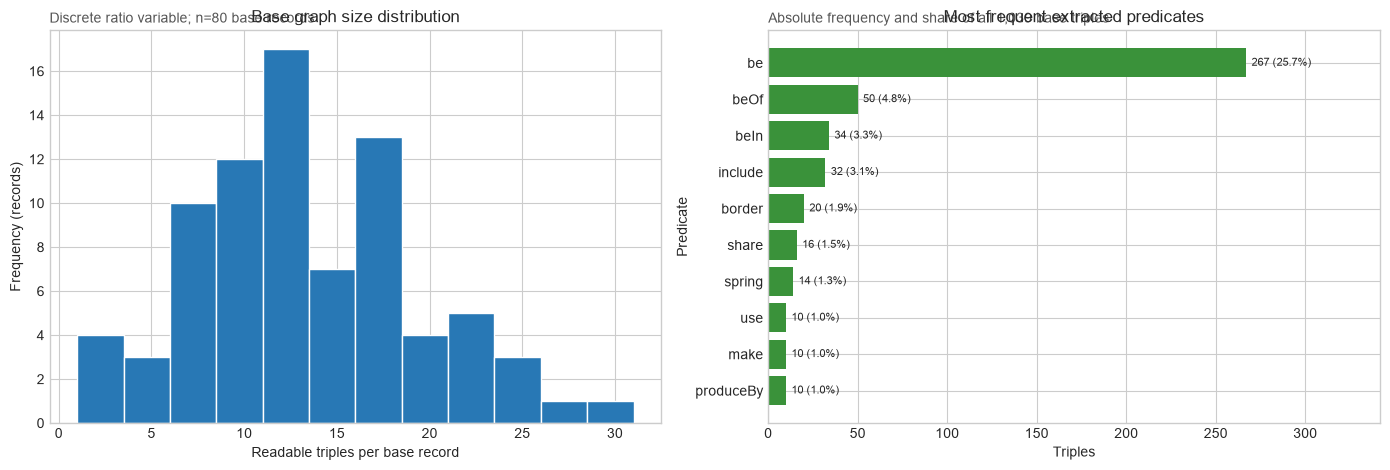

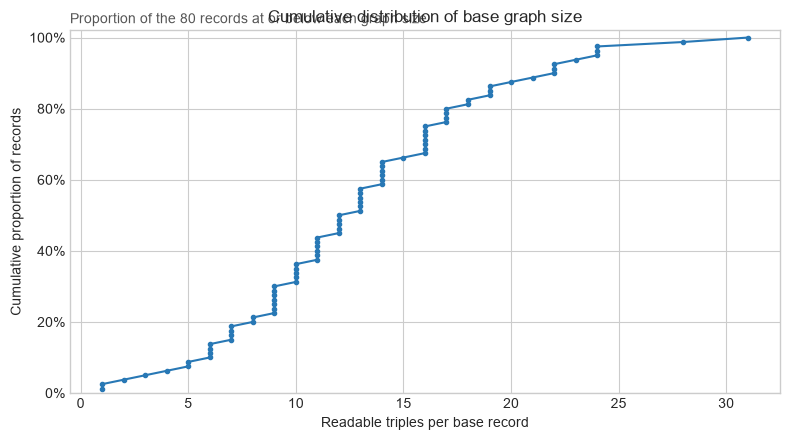

In [5]:
def flatten_triples(series):
    for triples in series.dropna():
        for triple in triples:
            if isinstance(triple, list) and len(triple) == 3:
                yield tuple(triple)

base_triples = list(flatten_triples(base["parsed_triples"]))
predicate_counts = Counter(predicate for _, predicate, _ in base_triples)

graph_profile = pd.DataFrame({
    "base_graph_triples": base["triple_count"].describe(),
    "combined_graph_triples": graphs["triple_count"].describe(),
}).round(1)
display(graph_profile)

triple_bins = [0, 5, 10, 15, 20, 25, 35]
base["triple_count_band"] = pd.cut(base["triple_count"], bins=triple_bins, right=True)
triple_frequency = base["triple_count_band"].value_counts(sort=False).rename("frequency").to_frame()
triple_frequency["percentage"] = triple_frequency["frequency"] / len(base) * 100
triple_frequency["cumulative_frequency"] = triple_frequency["frequency"].cumsum()
triple_frequency["cumulative_percentage"] = triple_frequency["percentage"].cumsum()
display(triple_frequency.round(1))

top_predicates = pd.DataFrame(predicate_counts.most_common(15), columns=["predicate", "triple_count"])
top_predicates["share"] = top_predicates["triple_count"] / len(base_triples)
top_predicates["cumulative_share"] = top_predicates["share"].cumsum()
display(top_predicates.style.format({"share": "{:.1%}", "cumulative_share": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(base["triple_count"], bins=12, color="#2878B5", edgecolor="white")
axes[0].set(title="Base graph size distribution", xlabel="Readable triples per base record", ylabel="Frequency (records)")
axes[0].text(0, 1.02, f"Discrete ratio variable; n={len(base)} base records", transform=axes[0].transAxes, color="#555555")
plot_predicates = top_predicates.head(10).sort_values("triple_count")
bars = axes[1].barh(plot_predicates["predicate"], plot_predicates["triple_count"], color="#3A923A")
axes[1].set(title="Most frequent extracted predicates", xlabel="Triples", ylabel="Predicate")
axes[1].text(0, 1.02, f"Absolute frequency and share of all {len(base_triples):,} base triples", transform=axes[1].transAxes, color="#555555")
for bar, (_, item) in zip(bars, plot_predicates.iterrows()):
    axes[1].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f"{int(item['triple_count'])} ({item['share']:.1%})", va="center", fontsize=8)
axes[1].set_xlim(0, plot_predicates["triple_count"].max() * 1.28)
plt.tight_layout()
plt.show()

sorted_counts = np.sort(base["triple_count"].astype(int).to_numpy())
cumulative_share = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sorted_counts, cumulative_share, marker="o", markersize=3, color="#2878B5")
ax.set(title="Cumulative distribution of base graph size", xlabel="Readable triples per base record", ylabel="Cumulative proportion of records")
ax.text(0, 1.02, f"Proportion of the {len(base)} records at or below each graph size", transform=ax.transAxes, color="#555555")
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

### 6. Validate readable triples and Turtle RDF

In [6]:
WD_PREFIX = "http://www.wikidata.org/entity/"
KG_PREFIX = "https://example.org/wikidata-description/"
RDFS_LABEL = URIRef("http://www.w3.org/2000/01/rdf-schema#label")

def parse_turtle(value):
    try:
        return Graph().parse(data=value, format="turtle"), ""
    except Exception as exc:
        return None, f"{type(exc).__name__}: {exc}"

def rdf_readable_triples(graph):
    labels_by_node = {str(subject): str(label) for subject, _, label in graph.triples((None, RDFS_LABEL, None))}
    result = set()
    for subject, predicate, obj in graph:
        if predicate == RDFS_LABEL:
            continue
        subject_label = labels_by_node.get(str(subject), str(subject).removeprefix(WD_PREFIX))
        object_label = labels_by_node.get(str(obj), str(obj).removeprefix(WD_PREFIX))
        predicate_label = str(predicate).removeprefix(KG_PREFIX)
        result.add((subject_label, predicate_label, object_label))
    return result

rdf_checks = []
parsed_base_graphs = {}
for row in base.itertuples(index=False):
    rdf_graph, error = parse_turtle(row.rdf)
    parsed_base_graphs[row.identifier] = rdf_graph
    readable = set(map(tuple, row.parsed_triples or []))
    reconstructed = rdf_readable_triples(rdf_graph) if rdf_graph is not None else set()
    rdf_checks.append({
        "identifier": row.identifier,
        "rdf_parses": rdf_graph is not None,
        "readable_matches_rdf": rdf_graph is not None and readable == reconstructed,
        "readable_only_edges": len(readable - reconstructed),
        "rdf_only_edges": len(reconstructed - readable),
        "error": error,
    })

rdf_checks = pd.DataFrame(rdf_checks)
display(rdf_checks.drop(columns="error").agg({
    "rdf_parses": ["sum", "count"],
    "readable_matches_rdf": ["sum", "count"],
    "readable_only_edges": "sum",
    "rdf_only_edges": "sum",
}))
display(rdf_checks.loc[~rdf_checks["rdf_parses"] | ~rdf_checks["readable_matches_rdf"]].head(10))

,rdf_parses,readable_matches_rdf,readable_only_edges,rdf_only_edges
sum,80,79,0.0,1.0
count,80,80,NaN,NaN


,identifier,rdf_parses,readable_matches_rdf,readable_only_edges,rdf_only_edges,error
70,Cat-Feline_01,True,False,0,1,


### 7. Reconcile combined graphs with their source pairs

In [7]:
base_by_id = base.set_index("identifier")
combined_checks = []

for row in graphs.itertuples(index=False):
    source_ids = [f"{row.identifier}_01", f"{row.identifier}_02"]
    sources_exist = all(source_id in base_by_id.index for source_id in source_ids)
    if not sources_exist:
        combined_checks.append({"identifier": row.identifier, "sources_exist": False})
        continue

    source_rows = [base_by_id.loc[source_id] for source_id in source_ids]
    expected_description = " ".join(source["description"] for source in source_rows)
    expected_readable = set().union(*(set(map(tuple, source["parsed_triples"] or [])) for source in source_rows))
    actual_readable = set(map(tuple, row.parsed_triples or []))

    combined_rdf, error = parse_turtle(row.rdf)
    source_rdf_union = Graph()
    for source_id in source_ids:
        if parsed_base_graphs[source_id] is not None:
            source_rdf_union += parsed_base_graphs[source_id]

    combined_checks.append({
        "identifier": row.identifier,
        "sources_exist": True,
        "description_matches": row.description == expected_description,
        "readable_union_matches": actual_readable == expected_readable,
        "rdf_union_matches": combined_rdf is not None and set(combined_rdf) == set(source_rdf_union),
        "combined_triples": len(actual_readable),
        "source_union_triples": len(expected_readable),
        "rdf_error": error,
    })

combined_checks = pd.DataFrame(combined_checks)
display(combined_checks[["sources_exist", "description_matches", "readable_union_matches", "rdf_union_matches"]].agg(["sum", "count"]))
display(combined_checks.loc[~combined_checks[["sources_exist", "description_matches", "readable_union_matches", "rdf_union_matches"]].all(axis=1)].head(10))

,sources_exist,description_matches,readable_union_matches,rdf_union_matches
sum,40,40,40,40
count,40,40,40,40


,identifier,sources_exist,description_matches,readable_union_matches,rdf_union_matches,combined_triples,source_union_triples,rdf_error


### 8. Profile question coverage and answer sets

,rows,share,percentage
query_type,,,
entity,80,50.0%,50.0%
predicate,80,50.0%,50.0%


Sources with exactly one entity and one predicate question: 80/80


,count,min,25%,50%,75%,max
query_type,,,,,,
entity,80.0,1.0,9.0,12.5,16.0,31.0
predicate,80.0,1.0,4.0,5.0,7.0,11.0


,answer_count,query_type,frequency,percentage_within_type,cumulative_percentage_within_type
0,1,entity,3,3.8%,3.8%
1,1,predicate,4,5.0%,5.0%
2,2,entity,1,1.2%,5.0%
3,2,predicate,3,3.8%,8.8%
4,3,entity,1,1.2%,6.2%
5,3,predicate,9,11.2%,20.0%
6,4,entity,1,1.2%,7.5%
7,4,predicate,12,15.0%,35.0%
8,5,entity,2,2.5%,10.0%
9,5,predicate,18,22.5%,57.5%


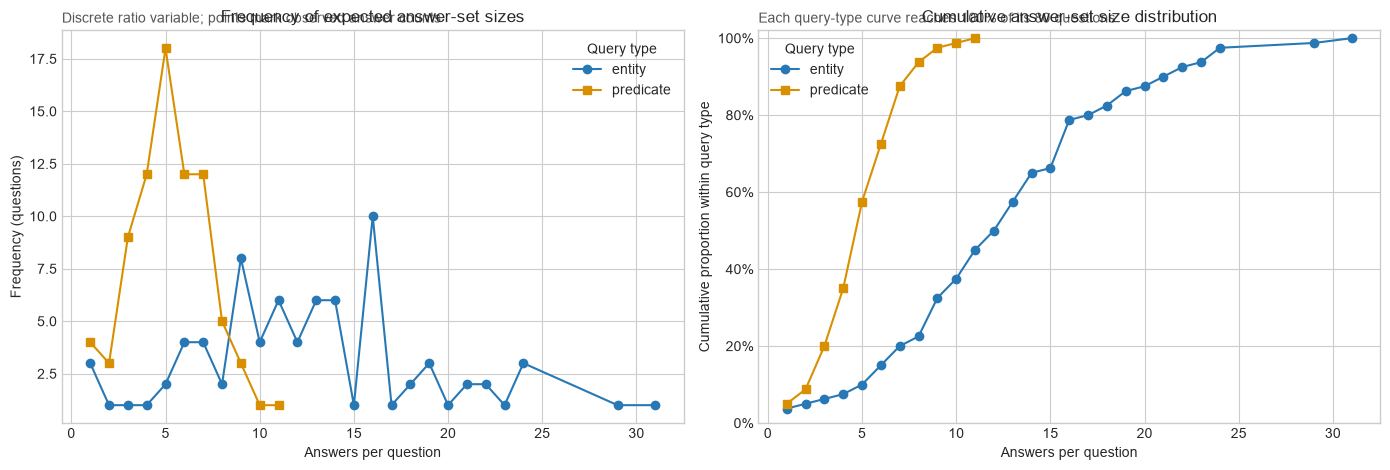

In [8]:
question_type_counts = labels["query_type"].value_counts().rename_axis("query_type").to_frame("rows")
question_type_counts["share"] = question_type_counts["rows"] / len(labels)
question_type_counts["percentage"] = question_type_counts["share"] * 100
display(question_type_counts.style.format({"share": "{:.1%}", "percentage": "{:.1f}%"}))

per_source_question_types = labels.groupby("description_identifier")["query_type"].agg(list)
sources_with_expected_types = per_source_question_types.apply(lambda values: sorted(values) == ["entity", "predicate"])
print(f"Sources with exactly one entity and one predicate question: {sources_with_expected_types.sum()}/{len(base)}")

answer_profile = labels.groupby("query_type")["answer_count"].describe()[["count", "min", "25%", "50%", "75%", "max"]]
display(answer_profile.round(1))

answer_frequency = labels.groupby(["answer_count", "query_type"]).size().rename("frequency").reset_index()
answer_frequency["percentage_within_type"] = answer_frequency.groupby("query_type")["frequency"].transform(lambda values: values / values.sum() * 100)
answer_frequency["cumulative_percentage_within_type"] = answer_frequency.groupby("query_type")["percentage_within_type"].cumsum()
display(answer_frequency.head(20).style.format({"percentage_within_type": "{:.1f}%", "cumulative_percentage_within_type": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
styles = {"entity": ("#2878B5", "o"), "predicate": ("#D99000", "s")}
for query_type, group in answer_frequency.groupby("query_type"):
    color, marker = styles[query_type]
    axes[0].plot(group["answer_count"], group["frequency"], marker=marker, color=color, label=query_type)
    axes[1].plot(group["answer_count"], group["cumulative_percentage_within_type"] / 100, marker=marker, color=color, label=query_type)
axes[0].set(title="Frequency of expected answer-set sizes", xlabel="Answers per question", ylabel="Frequency (questions)")
axes[0].text(0, 1.02, "Discrete ratio variable; points mark observed answer counts", transform=axes[0].transAxes, color="#555555")
axes[1].set(title="Cumulative answer-set size distribution", xlabel="Answers per question", ylabel="Cumulative proportion within query type")
axes[1].text(0, 1.02, "Each query-type curve reaches 100% of its 80 questions", transform=axes[1].transAxes, color="#555555")
axes[1].set_ylim(0, 1.02)
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
for ax in axes:
    ax.legend(title="Query type")
plt.tight_layout()
plt.show()

### 9. Execute SPARQL and reconcile stored answers

In [9]:
def normalize_result(value):
    text = str(value)
    return f"wd:{text.removeprefix(WD_PREFIX)}" if text.startswith(WD_PREFIX) else text

def execute_first_column(graph, query):
    try:
        values = {normalize_result(row[0]) for row in graph.query(query) if row}
        return sorted(values, key=str.casefold), ""
    except Exception as exc:
        return None, f"{type(exc).__name__}: {exc}"

label_execution = []
for row in labels.itertuples(index=False):
    graph = parsed_base_graphs.get(row.description_identifier)
    actual, error = execute_first_column(graph, row.sparql) if graph is not None else (None, "source RDF unavailable")
    expected = row.parsed_answer
    label_execution.append({
        "identifier": row.identifier,
        "source": row.description_identifier,
        "query_type": row.query_type,
        "executes": actual is not None,
        "exact_set_match": actual is not None and set(actual) == set(expected or []),
        "actual_count": len(actual) if actual is not None else np.nan,
        "expected_count": len(expected) if expected is not None else np.nan,
        "error": error,
    })
label_execution = pd.DataFrame(label_execution)

id_execution = []
for row in ids.itertuples(index=False):
    graph = parsed_base_graphs.get(row.description_identifier)
    actual, error = execute_first_column(graph, row.id_sparql) if graph is not None else (None, "source RDF unavailable")
    id_execution.append({
        "identifier": row.identifier,
        "source": row.description_identifier,
        "executes": actual is not None,
        "returns_expected_id": actual is not None and row.answer_id in actual,
        "actual": actual,
        "expected": row.answer_id,
        "error": error,
    })
id_execution = pd.DataFrame(id_execution)

execution_summary = pd.DataFrame([
    {"query_family": "label", "queries": len(label_execution), "execute": int(label_execution["executes"].sum()), "reproduce_expected": int(label_execution["exact_set_match"].sum())},
    {"query_family": "id", "queries": len(id_execution), "execute": int(id_execution["executes"].sum()), "reproduce_expected": int(id_execution["returns_expected_id"].sum())},
])
execution_summary["execution_rate"] = execution_summary["execute"] / execution_summary["queries"]
execution_summary["reproduction_rate"] = execution_summary["reproduce_expected"] / execution_summary["queries"]
display(execution_summary.style.format({"execution_rate": "{:.1%}", "reproduction_rate": "{:.1%}"}))

display(label_execution.loc[~label_execution["executes"] | ~label_execution["exact_set_match"]].head(10))
display(id_execution.loc[~id_execution["executes"] | ~id_execution["returns_expected_id"]].head(10))

,query_family,queries,execute,reproduce_expected,execution_rate,reproduction_rate
0,label,160,160,160,100.0%,100.0%
1,id,79,79,79,100.0%,100.0%


,identifier,source,query_type,executes,exact_set_match,actual_count,expected_count,error


,identifier,source,executes,returns_expected_id,actual,expected,error


### 10. Explore the relationship between description length and graph size

,records,mean_description_words,median_description_words,mean_triples,median_triples
sense,,,,,
01,40,39.48,39.0,12.58,12.0
02,40,40.25,36.5,13.40,13.0


,method,association,observations
0,Pearson,0.773,80
1,Spearman,0.718,80


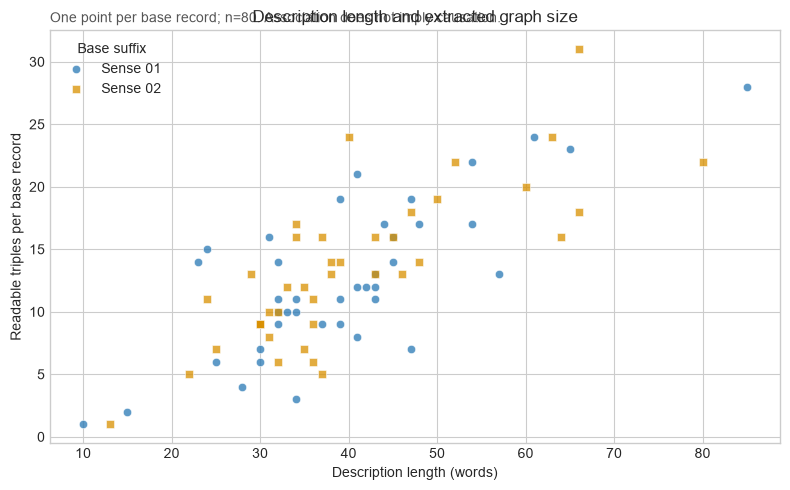

In [10]:
relationship_summary = base.groupby("sense").agg(
    records=("identifier", "size"),
    mean_description_words=("description_words", "mean"),
    median_description_words=("description_words", "median"),
    mean_triples=("triple_count", "mean"),
    median_triples=("triple_count", "median"),
).round(2)

correlation_table = pd.DataFrame({
    "method": ["Pearson", "Spearman"],
    "association": [
        base["description_words"].corr(base["triple_count"], method="pearson"),
        base["description_words"].rank().corr(base["triple_count"].rank(), method="pearson"),
    ],
    "observations": [len(base), len(base)],
})
display(relationship_summary)
display(correlation_table.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
point_styles = {"01": ("#2878B5", "o"), "02": ("#D99000", "s")}
for sense, group in base.groupby("sense"):
    color, marker = point_styles[sense]
    ax.scatter(group["description_words"], group["triple_count"], label=f"Sense {sense}", color=color, marker=marker, alpha=0.75, edgecolor="white", linewidth=0.5)
ax.set(title="Description length and extracted graph size", xlabel="Description length (words)", ylabel="Readable triples per base record")
ax.text(0, 1.02, f"One point per base record; n={len(base)}. Association does not imply causation.", transform=ax.transAxes, color="#555555")
ax.legend(title="Base suffix")
plt.tight_layout()
plt.show()

### 11. Surface records for semantic review

In [11]:
# Structural checks cannot determine whether a resolved label is semantically relevant.
# This table prioritizes review using graph size and rare/unusual object labels; it does not label errors automatically.
object_counts = Counter(obj for _, _, obj in base_triples)
review_candidates = []
for row in base.itertuples(index=False):
    triples = list(map(tuple, row.parsed_triples or []))
    rare_objects = [obj for _, _, obj in triples if object_counts[obj] == 1]
    review_candidates.append({
        "identifier": row.identifier,
        "triple_count": len(triples),
        "unique_objects": len({obj for _, _, obj in triples}),
        "singleton_objects": len(rare_objects),
        "example_singleton_objects": ", ".join(rare_objects[:5]),
        "description_preview": row.description[:140] + ("…" if len(row.description) > 140 else ""),
    })

review_candidates = pd.DataFrame(review_candidates).sort_values(
    ["singleton_objects", "triple_count"], ascending=False
)
display(review_candidates.head(15))

,identifier,triple_count,unique_objects,singleton_objects,example_singleton_objects,description_preview
29,Spring_02,31,31,29,"Antoine, Arthur, Belgian Species List, botanist, Bryan","The surname Spring is shared by: Amos Spring, English cricketer Antoine Frédéric Spring, Belgian..."
23,Bank_02,24,24,21,"actor, association football coach, association football player, basketball, Danish","Bank is a surname. Notable people with the surname include: Floyd Bank, American former basketba..."
30,Turkey_01,24,24,19,"Aegean Airlines, Aegean Sea, Armenia, Azerbaijan, Black","Turkey, officially the Republic of Türkiye, is a country mainly located in Anatolia in West Asia..."
70,Cat-Feline_01,28,28,18,"Balearic, Catalonia, community, island, Romance","Catalan is a Western Romance language that is native to, and the official language of, three aut..."
5,Apple_02,22,22,17,"British Phonographic Industry, originally, The Beatles, 1968, Apple Corps",Apple Records is a British record label founded by the Beatles in 1968 as a division of Apple Co...
74,Country-Nation_01,22,22,17,"Acoustic, Electric, fiddle, guitar, Guitars","Country music, also known as country and western or simply country, is a music genre originating..."
50,House-Building_01,19,19,17,"building, residential community, single-unit recording, systems, Air",A house is a single-unit residential building. It may range in complexity from a rudimentary hut...
51,House-Building_02,24,24,16,"immunologic factor, Numerous factors and incorrect measurements can lead to misinterpretations. ...","A building or edifice is an enclosed structure with a roof, walls and often windows, usually sta..."
21,Crane_02,20,20,16,"advantage, ventilator, side-scrolling video game, vertically transmitted infection, heavy metal ...","A crane is a machine used to move materials both vertically and horizontally, utilizing a system..."
60,Author-Novelist_01,23,23,15,"Research Papers in Economics, emotion, Feelings, play, Travelogues","A writer is a person who uses written words in different writing styles, genres, and techniques ..."


### 12. Consolidated data-quality issues

In [12]:
issues = []

def add_issue(severity, check, evidence, impact, identifiers=""):
    issues.append({"severity": severity, "check": check, "evidence": evidence, "impact": impact, "identifiers": identifiers})

if missing_id_sources:
    add_issue(
        "Medium", "ID-question coverage",
        f"{len(missing_id_sources)} of {len(base)} base records has no ID question.",
        "ID-based evaluation is not fully balanced across base records.",
        ", ".join(missing_id_sources),
    )
if not rdf_checks["rdf_parses"].all():
    failed = rdf_checks.loc[~rdf_checks["rdf_parses"], "identifier"].tolist()
    add_issue("High", "Turtle parsing", f"{len(failed)} RDF documents failed to parse.", "Affected graphs cannot be queried reliably.", ", ".join(failed[:20]))
if not rdf_checks["readable_matches_rdf"].all():
    failed = rdf_checks.loc[~rdf_checks["readable_matches_rdf"], "identifier"].tolist()
    add_issue("High", "Readable/RDF edge agreement", f"{len(failed)} base records disagree.", "Human-readable and machine-readable ground truth diverge.", ", ".join(failed[:20]))
if not combined_checks.get("rdf_union_matches", pd.Series(dtype=bool)).all():
    failed = combined_checks.loc[~combined_checks["rdf_union_matches"], "identifier"].tolist()
    add_issue("High", "Combined graph reconciliation", f"{len(failed)} combined RDF graphs differ from their source union.", "Combined-graph evaluation may use inconsistent evidence.", ", ".join(failed[:20]))
if not label_execution["exact_set_match"].all():
    failed = label_execution.loc[~label_execution["exact_set_match"], "identifier"].tolist()
    add_issue("High", "Label-answer reproducibility", f"{len(failed)} label queries do not exactly reproduce stored answer sets.", "Stored ground truth may not match query behavior.", ", ".join(failed[:20]))
if not id_execution["returns_expected_id"].all():
    failed = id_execution.loc[~id_execution["returns_expected_id"], "identifier"].tolist()
    add_issue("High", "ID-answer reproducibility", f"{len(failed)} ID queries do not return the expected Q-ID.", "Directed ID evaluation may be invalid.", ", ".join(failed[:20]))

add_issue(
    "Open review", "Semantic relevance",
    "Syntactic checks cannot establish that extracted Wikidata labels are supported by the source descriptions.",
    "Semantically incorrect triples can inflate or distort benchmark results.",
    "Use the stratified review candidates above.",
)

issues_df = pd.DataFrame(issues)
severity_order = pd.CategoricalDtype(["Critical", "High", "Medium", "Low", "Open review"], ordered=True)
issues_df["severity"] = issues_df["severity"].astype(severity_order)
issues_df = issues_df.sort_values("severity").reset_index(drop=True)
display(issues_df)

,severity,check,evidence,impact,identifiers
0,High,Readable/RDF edge agreement,1 base records disagree.,Human-readable and machine-readable ground truth diverge.,Cat-Feline_01
1,Medium,ID-question coverage,1 of 80 base records has no ID question.,ID-based evaluation is not fully balanced across base records.,Mustang_02
2,Open review,Semantic relevance,Syntactic checks cannot establish that extracted Wikidata labels are supported by the source des...,Semantically incorrect triples can inflate or distort benchmark results.,Use the stratified review candidates above.


## Takeaways

1. **Structural coverage is strong but not perfectly uniform.** The expected base-pair, combined-graph, and label-question relationships can be tested deterministically. The uncovered ID source (`Mustang_02`) should be explained before ID-based results are aggregated without qualification.
2. **Machine-readable consistency is measurable.** JSON parsing, Turtle parsing, readable/RDF edge agreement, combined-graph union checks, and local SPARQL reproduction provide hard quality gates. Refer to the executed tables above for the current pass/fail counts.
3. **Semantic correctness remains the principal open risk.** Entity resolution can produce valid Wikidata IDs and executable graphs while still linking text to an unrelated concept. A stratified manual review is required before the dataset is treated as reliable ground truth.
4. **Future benchmark splits must be root-grouped.** Both senses (`_01`, `_02`), their combined graph, and all derived questions should remain in the same split to prevent leakage.
5. **Recommended next step:** annotate a shared, stratified subset of triples as `correct`, `plausible`, `incorrect`, or `unclear`, then report agreement and error rates by predicate and graph-size tier.

### Limitations

- This notebook profiles the current local snapshot and has no historical data for drift or freshness analysis.
- It does not verify descriptions or labels against live Wikipedia/Wikidata sources.
- Heuristic review prioritization is not an automatic semantic error detector.